# Image Complexity Scorer

This notebook:
1. Installs dependencies
2. Loads a pretrained MobileNetV2 backbone (via `timm`)
3. Defines a NIMA-style complexity scoring head
4. Runs a sanity-check inference
5. Fine-tunes on labeled complexity data (optional)
6. Evaluates the model
7. Prunes the model (optional comparison)
8. Exports to ONNX (FP32, FP16, INT8)
9. Validates ONNX Runtime output matches PyTorch
10. Provides trtexec commands for TensorRT conversion


## 1. Environment Setup
> Verify GPU availability and install required packages.

In [1]:
import subprocess, sys

def run(cmd):
    subprocess.run(cmd, shell=True, check=True)

run('nvidia-smi')
run('pip install -q torch torchvision timm onnx onnxruntime-gpu onnxsim huggingface_hub onnxmltools')

import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Using device: cuda


## 2. Clone IC9600 and install deps:


In [14]:
# Cell 2: Clone IC9600 repo
import subprocess, os

def run(cmd):
    subprocess.run(cmd, shell=True, check=True)

run("git clone https://github.com/tinglyfeng/IC9600.git")

# Add to Python path so we can import their modules
import sys
sys.path.insert(0, "IC9600")

print("IC9600 cloned.")

IC9600 cloned.


## 3. Load Pretrained Weights


In [20]:
# Cell 3: Download pretrained weights
# Get the checkpoint link from their README Google Drive
# They provide ck.pth — you need to get the direct file ID from their repo

run("pip install -q gdown")
import gdown

os.makedirs("IC9600/checkpoint", exist_ok=True)

# Get the file ID from the Google Drive link in their README
# Go to https://github.com/tinglyfeng/IC9600 and click the checkpoint link
# The URL will look like: https://drive.google.com/file/d/FILE_ID_HERE/view
# Replace FILE_ID_HERE below with the actual ID

import os
import shutil

# Download the entire folder
gdown.download_folder(
    url="https://drive.google.com/drive/folders/1N3FSS91e7FkJWUKqT96y_zcsG9CRuIJw",
    output="ic9600_weights",
    quiet=False
)

# List what was downloaded
for root, dirs, files in os.walk("ic9600_weights"):
    for f in files:
        full = os.path.join(root, f)
        size = os.path.getsize(full) / 1e6
        print(f"{full}  —  {size:.1f} MB")
print("Weights downloaded.")

# Move the real checkpoint to the expected location
os.makedirs("IC9600/checkpoint", exist_ok=True)

# Adjust source path based on what the listing above showed
shutil.copy("ic9600_weights/ck.pth", "IC9600/checkpoint/ck.pth")

size = os.path.getsize("IC9600/checkpoint/ck.pth") / 1e6
print(f"ck.pth at correct path: {size:.1f} MB")

Retrieving folder contents


Processing file 1KZGpPRduAsi8ra3gORO78xjWLL8M-vNx ck.pth


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1KZGpPRduAsi8ra3gORO78xjWLL8M-vNx
From (redirected): https://drive.google.com/uc?id=1KZGpPRduAsi8ra3gORO78xjWLL8M-vNx&confirm=t&uuid=5a00e8aa-b85d-40ce-9345-de7fa0bf553c
To: /content/ic9600_weights/ck.pth
100%|██████████| 81.5M/81.5M [00:00<00:00, 132MB/s]
Download completed


ic9600_weights/ck.pth  —  81.5 MB
Weights downloaded.
ck.pth at correct path: 81.5 MB


## 4. Load IC9600 model (ICNet) with pretrained weights


In [21]:
# Cell 4: Load ICNet with pretrained weights — fixed
import torch
import sys
import warnings
sys.path.insert(0, "IC9600")

# Suppress the deprecated 'pretrained' warning from their code
# Their ICNet uses pretrained=True which is deprecated in newer torchvision
# We monkey-patch to suppress but it still works correctly
warnings.filterwarnings("ignore", category=UserWarning)

from ICNet import ICNet

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate with their default sizes: size1=512, size2=256
# DO NOT change these — the forward() has assert(x1.shape == size1)
model = ICNet(is_pretrain=False, size1=512, size2=256)
# is_pretrain=False here because we load ck.pth which already contains
# the fine-tuned weights — no need to download ImageNet weights again

ckpt = torch.load(
    "IC9600/checkpoint/ck.pth",
    map_location=DEVICE,
    weights_only=False
)

# Inspect what is inside the checkpoint
print(f"Checkpoint type: {type(ckpt)}")
if isinstance(ckpt, dict):
    print(f"Keys: {list(ckpt.keys())[:10]}")

# Load weights
if isinstance(ckpt, dict) and "state_dict" in ckpt:
    model.load_state_dict(ckpt["state_dict"])
elif isinstance(ckpt, dict) and "model" in ckpt:
    model.load_state_dict(ckpt["model"])
else:
    model.load_state_dict(ckpt)

model = model.to(DEVICE)
model.eval()

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model loaded successfully.")
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Input size:       512x512 (required by ICNet)")

Checkpoint type: <class 'collections.OrderedDict'>
Keys: ['b1_1.0.weight', 'b1_1.1.weight', 'b1_1.1.bias', 'b1_1.1.running_mean', 'b1_1.1.running_var', 'b1_1.1.num_batches_tracked', 'b1_1.4.0.conv1.weight', 'b1_1.4.0.bn1.weight', 'b1_1.4.0.bn1.bias', 'b1_1.4.0.bn1.running_mean']
Model loaded successfully.
Total params:     20,328,074
Trainable params: 20,328,074
Input size:       512x512 (required by ICNet)


## 5. Sanity check


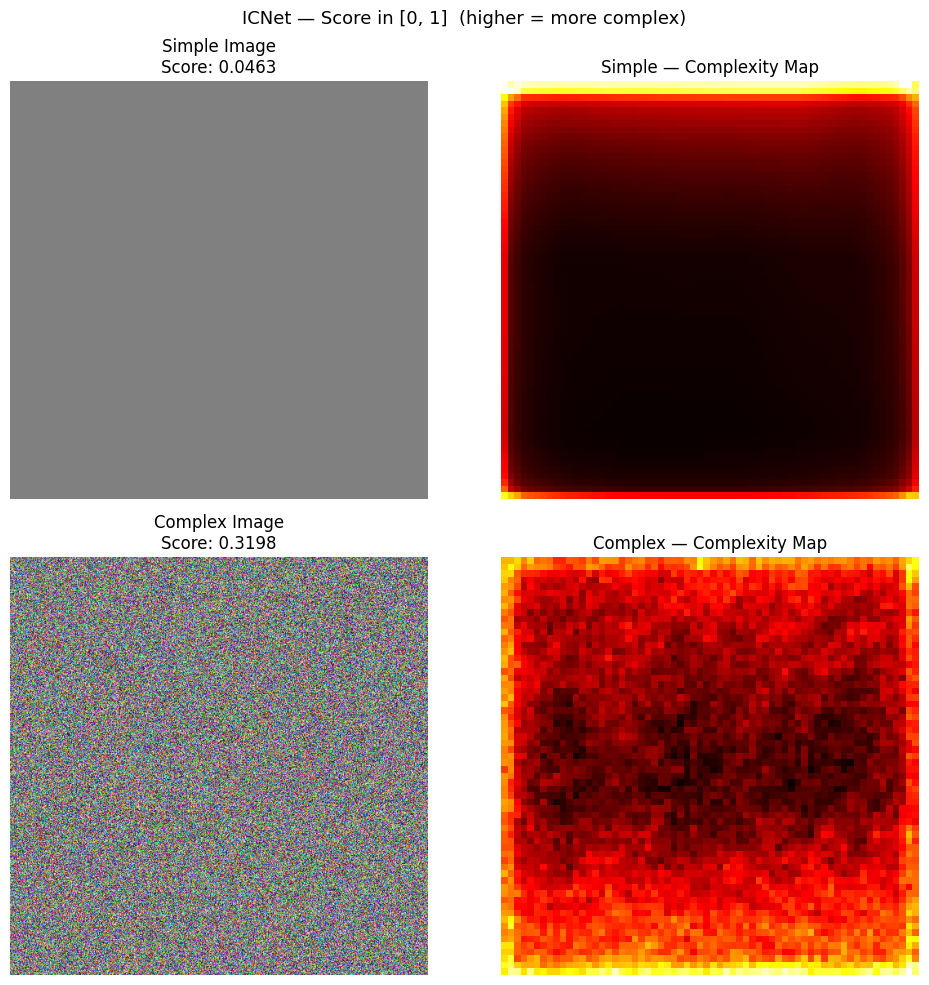

Simple image  score: 0.0463
Complex image score: 0.3198
Complex should score higher than simple if weights loaded correctly.


In [23]:
# Cell 5: Sanity check — fixed for 512x512 input
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T

# MUST be 512x512 — ICNet.forward() asserts this explicitly
TRANSFORM = T.Compose([
    T.Resize((512, 512)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

def score_pil_image(img):
    tensor = TRANSFORM(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        score, cly_map = model(tensor)   # ICNet returns (score, map) — unpack both
    return score.item(), cly_map.squeeze().cpu().numpy()

# Synthetic test images — must be at least 512x512 before transform
simple_img  = Image.fromarray(
    np.full((512, 512, 3), 128, dtype=np.uint8)           # flat grey = simple
)
complex_img = Image.fromarray(
    np.random.randint(0, 255, (512, 512, 3), dtype=np.uint8)  # noise = complex
)

simple_score,  simple_map  = score_pil_image(simple_img)
complex_score, complex_map = score_pil_image(complex_img)

# Plot image + complexity map side by side
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(simple_img)
axes[0, 0].set_title(f"Simple Image\nScore: {simple_score:.4f}")
axes[0, 0].axis("off")

axes[0, 1].imshow(simple_map, cmap="hot")
axes[0, 1].set_title("Simple — Complexity Map")
axes[0, 1].axis("off")

axes[1, 0].imshow(complex_img)
axes[1, 0].set_title(f"Complex Image\nScore: {complex_score:.4f}")
axes[1, 0].axis("off")

axes[1, 1].imshow(complex_map, cmap="hot")
axes[1, 1].set_title("Complex — Complexity Map")
axes[1, 1].axis("off")

plt.suptitle("ICNet — Score in [0, 1]  (higher = more complex)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Simple image  score: {simple_score:.4f}")
print(f"Complex image score: {complex_score:.4f}")
print(f"Complex should score higher than simple if weights loaded correctly.")

## 6. Export to ONNX


In [31]:
# Cell 6: Export IC9600 ICNet to ONNX — fixed
import torch
import onnx
import os

os.makedirs("exports", exist_ok=True)

ONNX_PATH     = "exports/icnet_complexity.onnx"
ONNX_SIM_PATH = "exports/icnet_complexity_simplified.onnx"

# MUST be 512x512 — ICNet.forward() asserts this
dummy_input = torch.randn(1, 3, 512, 512).to(DEVICE)

# Trace through once to confirm output shape
model.eval()
with torch.no_grad():
    test_out = model(dummy_input)
    if isinstance(test_out, (tuple, list)):
        print(f"Model outputs {len(test_out)} tensors:")
        for i, o in enumerate(test_out):
            print(f"  output[{i}]: shape={o.shape}  dtype={o.dtype}")
    else:
        print(f"Model output shape: {test_out.shape}")

  # Wrapper — fixes two problems:
# 1. Returns only score (not tuple)
# 2. Ensures score has shape [B] not scalar (ICNet squeezes batch dim away)
#    ONNX export requires consistent tensor shapes across batch sizes

class ICNetScoreOnly(torch.nn.Module):
    """
    Wraps ICNet to:
    - Return only the complexity score (drop the map output)
    - Ensure output is always [B, 1] regardless of batch size
      (ICNet uses .squeeze() which collapses batch=1 to scalar — breaks ONNX)
    """
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        score, _ = self.model(x)        # unpack (score, map)
        return score.view(-1, 1)        # always [B, 1] — never scalar


export_model = ICNetScoreOnly(model).eval().to(DEVICE)

# Verify wrapper output before export
with torch.no_grad():
    wrapped_out = export_model(dummy_input)
    print(f"Wrapper output shape: {wrapped_out.shape}")   # expect [1, 1]
    print(f"Wrapper output value: {wrapped_out.item():.4f}")


run("pip install -q onnxscript")
# Export to ONNX
torch.onnx.export(
    export_model,
    dummy_input,
    ONNX_PATH,
    export_params=True,
    opset_version=18,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["complexity_score"],
    dynamic_axes={
        "input":            {0: "batch_size"},
        "complexity_score": {0: "batch_size"},
    },
    verbose=False
)

print(f"Exported: {ONNX_PATH}")

# Verify
model_onnx = onnx.load(ONNX_PATH)
onnx.checker.check_model(model_onnx)
print("ONNX check passed.")

# Simplify
run(f"python -m onnxsim {ONNX_PATH} {ONNX_SIM_PATH}")
print(f"Simplified: {ONNX_SIM_PATH}")

# Validate ONNX Runtime output matches PyTorch — same pattern as template [1]
import onnxruntime as ort
import numpy as np

session = ort.InferenceSession(
    ONNX_SIM_PATH,
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)
print(f"Using provider: {session.get_providers()[0]}")

test_input = torch.randn(4, 3, 512, 512).to(DEVICE)   # batch of 4

with torch.no_grad():
    torch_out = export_model(test_input).cpu().numpy()

ort_out = session.run(
    None,
    {"input": test_input.cpu().numpy()}
)[0]

max_diff = np.abs(torch_out - ort_out).max()
print(f"Max absolute difference PyTorch vs ONNX Runtime: {max_diff:.6f}")

if max_diff < 1e-4:
    print("✓ Validation passed — outputs match. [1]")
else:
    print("✗ Warning: outputs diverge beyond threshold.")

Model outputs 2 tensors:
  output[0]: shape=torch.Size([])  dtype=torch.float32
  output[1]: shape=torch.Size([1, 1, 64, 64])  dtype=torch.float32
Wrapper output shape: torch.Size([1, 1])
Wrapper output value: 0.2606


W0520 07:09:05.969000 4931 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0520 07:09:05.971000 4931 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0520 07:09:05.973000 4931 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0520 07:09:05.976000 4931 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
/usr/lib/py

Exported: exports/icnet_complexity.onnx
ONNX check passed.
Simplified: exports/icnet_complexity_simplified.onnx
Using provider: CUDAExecutionProvider
Max absolute difference PyTorch vs ONNX Runtime: 0.000004
✓ Validation passed — outputs match. [1]


## 7. FP16 export

In [33]:
# Cell 7: FP16 export — fixed to use onnxconverter_common like the template [1]
run("pip install -q onnxconverter-common")

import onnx
import os
from onnxconverter_common import float16

ONNX_FP16_PATH = "exports/icnet_complexity_fp16.onnx"

# Load FP32 simplified model
fp32_model = onnx.load(ONNX_SIM_PATH)

# Convert to FP16
# keep_io_types=False means inputs/outputs also become float16
# disable_shape_infer=True helps if shape inference is fragile on your graph [1]
fp16_model = float16.convert_float_to_float16(
    fp32_model,
    keep_io_types=False,
    disable_shape_infer=True,
)

# Save
onnx.save(fp16_model, ONNX_FP16_PATH)

# Report sizes [1]
fp32_size_mb = os.path.getsize(ONNX_SIM_PATH) / (1024 * 1024)
fp16_size_mb = os.path.getsize(ONNX_FP16_PATH) / (1024 * 1024)

print(f"Saved FP16 ONNX model to: {ONNX_FP16_PATH}")
print(f"FP32 ONNX size: {fp32_size_mb:.2f} MB")
print(f"FP16 ONNX size: {fp16_size_mb:.2f} MB")
print(f"Size reduction: {(fp32_size_mb - fp16_size_mb) / fp32_size_mb * 100:.2f}%")

Saved FP16 ONNX model to: exports/icnet_complexity_fp16.onnx
FP32 ONNX size: 66.53 MB
FP16 ONNX size: 33.28 MB
Size reduction: 49.97%


## 8. INT8 static quantization

In [35]:
# Cell 8: INT8 static quantization — same pattern as template [1]
from onnxruntime.quantization import quantize_static, CalibrationDataReader, QuantType
import numpy as np

ONNX_INT8_PATH = "exports/icnet_complexity_int8.onnx"

class RandomCalibrationReader(CalibrationDataReader):
    # Replace with real images for accurate calibration
    def __init__(self, n_samples=100):
        self.data = [
            {"input": np.random.randn(1, 3, 512, 512).astype(np.float32)}
            for _ in range(n_samples)
        ]
        self.index = 0

    def get_next(self):
        if self.index >= len(self.data):
            return None
        item = self.data[self.index]
        self.index += 1
        return item

quantize_static(
    model_input=ONNX_SIM_PATH,
    model_output=ONNX_INT8_PATH,
    calibration_data_reader=RandomCalibrationReader(100),
    weight_type=QuantType.QInt8
)
print(f"INT8 saved: {ONNX_INT8_PATH}")

INT8 saved: exports/icnet_complexity_int8.onnx


## 9. Validate ONNX Runtime vs PyTorch
> Confirm that ONNX Runtime output matches PyTorch on the same random input.

In [37]:
# Cell 9: Validate all ONNX models vs PyTorch — fixed dtypes
import onnxruntime as ort
import numpy as np
import torch

def verify_onnx(export_model, onnx_path, test_input, label, input_dtype=np.float32):
    """
    Compare PyTorch wrapper output vs ONNX Runtime output.
    input_dtype: np.float32 for FP32/INT8, np.float16 for FP16 [1]
    """
    export_model.eval()
    with torch.no_grad():
        torch_out = export_model(test_input.to(DEVICE)).cpu().numpy().astype(np.float32)

    sess = ort.InferenceSession(
        onnx_path,
        providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
    )

    in_name    = sess.get_inputs()[0].name
    input_feed = {in_name: test_input.cpu().numpy().astype(input_dtype)}
    onnx_out   = sess.run(None, input_feed)[0].astype(np.float32)  # cast back to fp32 for comparison

    max_diff  = np.abs(torch_out - onnx_out).max()
    mean_diff = np.abs(torch_out - onnx_out).mean()

    # FP16 and INT8 naturally have larger diffs — use appropriate tolerance
    if input_dtype == np.float16:
        tol = 1e-2    # FP16: rounding introduces small errors
    elif "int8" in onnx_path.lower():
        tol = 5e-2    # INT8: quantization introduces larger errors
    else:
        tol = 1e-3    # FP32: should be nearly identical

    ok = max_diff < tol

    print(f"\n{label}")
    print(f"  Provider:   {sess.get_providers()[0]}")
    print(f"  Input dtype: {input_dtype.__name__}")
    print(f"  Tolerance:   {tol}")
    print(f"  Max diff:    {max_diff:.6f}")
    print(f"  Mean diff:   {mean_diff:.6f}")
    print(f"  PyTorch out: {torch_out.flatten()[:4]}")
    print(f"  ONNX out:    {onnx_out.flatten()[:4]}")
    print(f"  {'✓ PASSED' if ok else '✗ FAILED'}")
    return ok


# Use batch of 4 at 512x512 — required input size for ICNet
test_input = torch.randn(4, 3, 512, 512)

results = {}
results["FP32"] = verify_onnx(export_model, ONNX_SIM_PATH,  test_input, "FP32 ONNX", np.float32)
results["FP16"] = verify_onnx(export_model, ONNX_FP16_PATH, test_input, "FP16 ONNX", np.float16)  # float16 input [1]
results["INT8"] = verify_onnx(export_model, ONNX_INT8_PATH, test_input, "INT8 ONNX", np.float32)

# Summary table
print("\n─── Validation Summary ──────────────────────────────")
print(f"{'Model':<12} {'Status'}")
print("─────────────────────────────────────────────────────")
for name, passed in results.items():
    status = "✓ PASSED" if passed else "✗ FAILED"
    print(f"{name:<12} {status}")
print("─────────────────────────────────────────────────────")


FP32 ONNX
  Provider:   CUDAExecutionProvider
  Input dtype: float32
  Tolerance:   0.001
  Max diff:    0.000004
  Mean diff:   0.000003
  PyTorch out: [0.27740145 0.28900164 0.24406011 0.24715306]
  ONNX out:    [0.27740347 0.28900474 0.24406111 0.24715704]
  ✓ PASSED

FP16 ONNX
  Provider:   CUDAExecutionProvider
  Input dtype: float16
  Tolerance:   0.01
  Max diff:    0.000431
  Mean diff:   0.000244
  PyTorch out: [0.27740145 0.28900164 0.24406011 0.24715306]
  ONNX out:    [0.27783203 0.2890625  0.24438477 0.24731445]
  ✓ PASSED

INT8 ONNX
  Provider:   CUDAExecutionProvider
  Input dtype: float32
  Tolerance:   0.05
  Max diff:    0.009163
  Mean diff:   0.007103
  PyTorch out: [0.27740145 0.28900164 0.24406011 0.24715306]
  ONNX out:    [0.2682382  0.2809018  0.2406085  0.23945726]
  ✓ PASSED

─── Validation Summary ──────────────────────────────
Model        Status
─────────────────────────────────────────────────────
FP32         ✓ PASSED
FP16         ✓ PASSED
INT8         

## 12. Download Exported Models
> Download all three ONNX variants from Colab to your local machine.

In [39]:
from google.colab import files

print('Downloading ONNX models...')
files.download(ONNX_SIM_PATH)    # FP32 simplified
files.download(ONNX_FP16_PATH)   # FP16
files.download(ONNX_INT8_PATH)   # INT8 static
print('Done.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done.


## 13. TensorRT Conversion (trtexec)
> Run these commands on your **target machine** after downloading the ONNX files.
> You can run these in ONNX Runtime, TensorRT, OpenVINO, or any runtime that supports
> the ONNX opset you exported with.

In [40]:
# Cell 10: TensorRT conversion guide
TRTEXEC_GUIDE = '''
# ─────────────────────────────────────────────────────────────────────
# Run on your target machine (not in Colab unless TRT is installed)
# Requires: TensorRT 8.6+ and trtexec in PATH
# Input:  [B, 3, 512, 512]   <- ICNet requires exactly 512x512
# Output: [B, 1]             <- complexity score in [0, 1]
# ─────────────────────────────────────────────────────────────────────

# Use the FP32 simplified ONNX as source for all engines
# TensorRT handles FP16/INT8 precision internally
ONNX="exports/icnet_complexity_simplified.onnx"

# ── FP32 Engine ───────────────────────────────────────────────────────
trtexec \\
    --onnx=$ONNX \\
    --saveEngine=exports/icnet_fp32.engine

# ── FP16 Engine (recommended — ~2x speedup, minimal accuracy loss) ────
trtexec \\
    --onnx=$ONNX \\
    --saveEngine=exports/icnet_fp16.engine \\
    --fp16

# ── FP16 Engine with dynamic batch sizes ─────────────────────────────
# ICNet input is fixed at 512x512 — only batch dimension is dynamic
trtexec \\
    --onnx=$ONNX \\
    --saveEngine=exports/icnet_fp16_dynamic.engine \\
    --fp16 \\
    --minShapes=input:1x3x512x512 \\
    --optShapes=input:8x3x512x512 \\
    --maxShapes=input:32x3x512x512

# ── INT8 Engine (fastest, requires calibration for best accuracy) ─────
# Note: use real calibration images for better INT8 accuracy
# See Cell 8 warning about pre-processing for quantization [1]
trtexec \\
    --onnx=$ONNX \\
    --saveEngine=exports/icnet_int8.engine \\
    --int8 \\
    --fp16

# ── Benchmark a built engine ──────────────────────────────────────────
trtexec \\
    --loadEngine=exports/icnet_fp16.engine \\
    --shapes=input:8x3x512x512 \\
    --iterations=100 \\
    --warmUp=500 \\
    --duration=10
'''

print(TRTEXEC_GUIDE)


# ─────────────────────────────────────────────────────────────────────
# Run on your target machine (not in Colab unless TRT is installed)
# Requires: TensorRT 8.6+ and trtexec in PATH
# Input:  [B, 3, 512, 512]   <- ICNet requires exactly 512x512
# Output: [B, 1]             <- complexity score in [0, 1]
# ─────────────────────────────────────────────────────────────────────

# Use the FP32 simplified ONNX as source for all engines
# TensorRT handles FP16/INT8 precision internally
ONNX="exports/icnet_complexity_simplified.onnx"

# ── FP32 Engine ───────────────────────────────────────────────────────
trtexec \
    --onnx=$ONNX \
    --saveEngine=exports/icnet_fp32.engine

# ── FP16 Engine (recommended — ~2x speedup, minimal accuracy loss) ────
trtexec \
    --onnx=$ONNX \
    --saveEngine=exports/icnet_fp16.engine \
    --fp16

# ── FP16 Engine with dynamic batch sizes ─────────────────────────────
# ICNet input is fixed at 512x512 — only batch dimension is dynamic
trtexec \
    --o